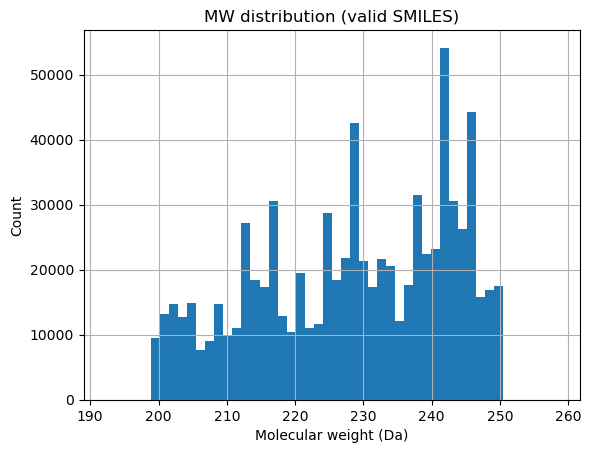

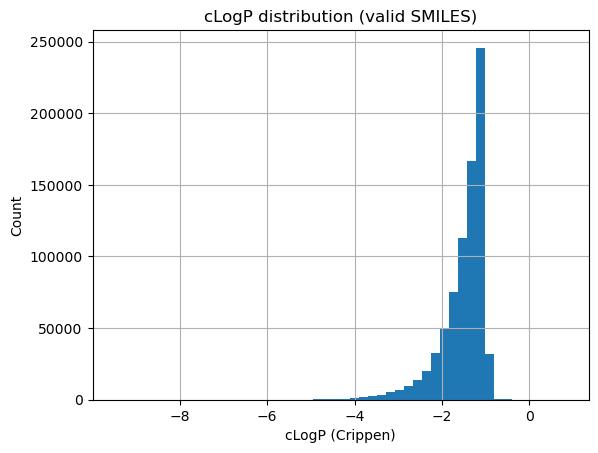

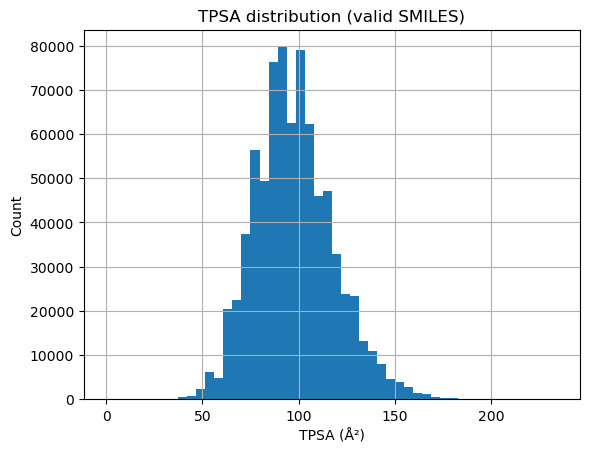

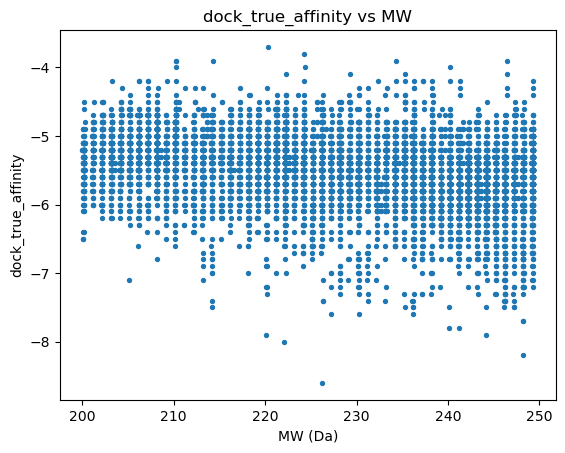

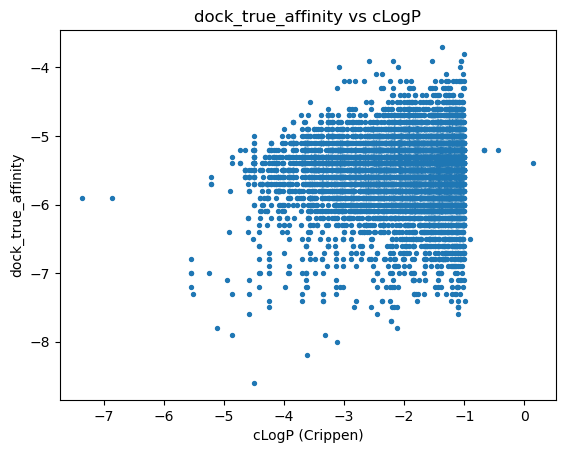

c:\Users\ASUS\miniconda3\envs\qsar\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Failed to find the pandas get_adjustment() function to patch              
Failed to patch pandas - PandasTools will have limited functionality


Triage tier counts:
triage_tier
Tier1_clean         459377
Tier3_alert_fail    296696
Tier2_borderline     25106

Saved augmented CSV to: df_triage.csv


In [2]:
# ==============================
# Step A + Step B: Descriptor diagnosis + Medchem triage
# - Reads your CSV (keeps all existing columns)
# - Adds RDKit physchem descriptors
# - Adds medchem rules + structural alert triage
# - Saves an augmented CSV and generates a few diagnostic plots
#
# References (APIs used):
# - medchem rules + functional filters: https://medchem-docs.datamol.io/stable/tutorials/Medchem_Rules.html
# - medchem alert_filter / rules_filter: https://medchem-docs.datamol.io/stable/api/medchem.functional.html
# ==============================

# ------------------------------
# 0) Imports
# ------------------------------
import pandas as pd  # tabular IO + joins
import numpy as np  # numeric ops + NaN handling
import matplotlib.pyplot as plt  # simple diagnostics plots

from rdkit import Chem  # molecule parsing
from rdkit.Chem import Descriptors  # MW, etc.
from rdkit.Chem import Crippen  # cLogP
from rdkit.Chem import Lipinski  # HBD/HBA/rotors
from rdkit.Chem import rdMolDescriptors  # TPSA, rings

import medchem as mc  # rules + alert catalogs (datamol-io/medchem)  # noqa: E402


# ------------------------------
# 1) User settings (edit these)
# ------------------------------
input_csv_path = "df_full_wo_features_with_ev.csv"  # path to your input CSV
output_csv_path = "df_triage.csv"  # path for augmented output

smiles_col = "SMILES"  # column name holding SMILES
score_col = "dock_true_affinity"  # docking score column used for plots

# Rule sets to apply (all must pass for "pass_all_rules")
# You can list available rules via: mc.rules.RuleFilters.list_available_rules()
rule_names = [
    "rule_of_five",          # classical drug-like guidance
    "rule_of_veber",         # oral-ish flexibility/polarity guidance
    "rule_of_pfizer_3_75",   # risk heuristic: avoid (TPSA<75 & logP>3)
    "rule_of_gsk_4_400",     # MW<=400 & logP<=4 (more conservative)
]

# Structural alert catalogs to screen (fail = matches an undesirable pattern)
# You can list default alert collections via: mc.structural.CommonAlertsFilters.list_default_available_alerts()
alert_collections = [
    "PAINS",                  # frequent assay interferers
    "Reactive-Unstable-Toxic", # broadly problematic reactivity/toxicophores
]

n_jobs = -1  # parallelism for medchem filters (-1 = all cores)


# ------------------------------
# 2) Load data (keeps all columns)
# ------------------------------
df = pd.read_csv(input_csv_path)  # read input as-is
df = df.copy()  # avoid modifying a view

# Ensure the SMILES column exists early (fail fast with a clear message)
if smiles_col not in df.columns:  # check schema
    raise ValueError(f"Missing required column '{smiles_col}' in {input_csv_path}")  # stop clearly


# ------------------------------
# 3) RDKit molecule parsing + physchem descriptors (Step A)
# ------------------------------
def _to_mol(smiles: str):  # small helper for robust parsing
    mol = Chem.MolFromSmiles(smiles) if isinstance(smiles, str) else None  # parse SMILES if string
    return mol  # return RDKit Mol or None

df["rdkit_mol"] = df[smiles_col].map(_to_mol)  # build molecule objects

df["is_valid_smiles"] = df["rdkit_mol"].map(lambda m: m is not None)  # validity flag

# Compute core physchem descriptors (NaN if invalid)
def _calc_desc(mol):  # compute a descriptor dict for one molecule
    if mol is None:  # handle invalid SMILES
        return {  # output NaNs so downstream stays numeric
            "MW": np.nan,
            "cLogP": np.nan,
            "HBD": np.nan,
            "HBA": np.nan,
            "TPSA": np.nan,
            "RotB": np.nan,
            "Rings": np.nan,
            "HeavyAtoms": np.nan,
            "FracCSP3": np.nan,
        }
    return {
        "MW": Descriptors.MolWt(mol),  # molecular weight
        "cLogP": Crippen.MolLogP(mol),  # Crippen logP
        "HBD": Lipinski.NumHDonors(mol),  # H-bond donors
        "HBA": Lipinski.NumHAcceptors(mol),  # H-bond acceptors
        "TPSA": rdMolDescriptors.CalcTPSA(mol),  # polar surface area
        "RotB": Lipinski.NumRotatableBonds(mol),  # flexibility proxy
        "Rings": rdMolDescriptors.CalcNumRings(mol),  # ring count
        "HeavyAtoms": mol.GetNumHeavyAtoms(),  # heavy atom count
        "FracCSP3": rdMolDescriptors.CalcFractionCSP3(mol),  # 3D-ness proxy
    }

desc_df = pd.DataFrame(df["rdkit_mol"].map(_calc_desc).tolist())  # expand descriptor dicts
df = pd.concat([df, desc_df], axis=1)  # append descriptors while keeping original columns


# ------------------------------
# 4) Quick diagnosis plots (Step A)
# ------------------------------
# Use only valid molecules for descriptor plots
valid_mask = df["is_valid_smiles"].to_numpy()  # boolean mask
df_valid = df.loc[valid_mask].copy()  # subset for plotting

# Only plot if we have something to plot
if len(df_valid) > 0:  # guard against empty input
    plt.figure()  # new figure
    df_valid["MW"].hist(bins=50)  # MW distribution
    plt.xlabel("Molecular weight (Da)")  # axis label
    plt.ylabel("Count")  # axis label
    plt.title("MW distribution (valid SMILES)")  # title
    plt.show()  # render

    plt.figure()  # new figure
    df_valid["cLogP"].hist(bins=50)  # logP distribution
    plt.xlabel("cLogP (Crippen)")  # axis label
    plt.ylabel("Count")  # axis label
    plt.title("cLogP distribution (valid SMILES)")  # title
    plt.show()  # render

    plt.figure()  # new figure
    df_valid["TPSA"].hist(bins=50)  # TPSA distribution
    plt.xlabel("TPSA (Å²)")  # axis label
    plt.ylabel("Count")  # axis label
    plt.title("TPSA distribution (valid SMILES)")  # title
    plt.show()  # render

    # If docking score exists, scatter score vs MW and logP (common “greasy/large scores better” artifact)
    if score_col in df_valid.columns:  # check score availability
        plt.figure()  # new figure
        plt.scatter(df_valid["MW"], df_valid[score_col], s=8)  # scatter points (no fixed colors)
        plt.xlabel("MW (Da)")  # axis label
        plt.ylabel(score_col)  # axis label
        plt.title(f"{score_col} vs MW")  # title
        plt.show()  # render

        plt.figure()  # new figure
        plt.scatter(df_valid["cLogP"], df_valid[score_col], s=8)  # scatter points (no fixed colors)
        plt.xlabel("cLogP (Crippen)")  # axis label
        plt.ylabel(score_col)  # axis label
        plt.title(f"{score_col} vs cLogP")  # title
        plt.show()  # render


# ------------------------------
# 5) Medchem triage: rules + alerts (Step B)
# ------------------------------
# Prepare list of molecules (medchem accepts Mol objects; keep ordering aligned with df rows)
mols = df["rdkit_mol"].tolist()  # list with None for invalid SMILES

# Apply medchem rules via RuleFilters object (returns per-rule booleans + pass_all/pass_any)
rfilter = mc.rules.RuleFilters(  # instantiate rule filter set
    rule_list=rule_names,  # rules by name (strings)
    rule_list_names=rule_names,  # explicit names for output columns
)

rules_result = rfilter(  # run rule checks
    mols=mols,  # molecules list
    n_jobs=n_jobs,  # parallel jobs
    progress=True,  # show progress bar
    progress_leave=False,  # do not persist bar after completion
    scheduler="auto",  # let medchem choose threads/processes
    keep_props=False,  # keep output lean
    fail_if_invalid=False,  # do not crash on invalid SMILES
)

# Merge rule outputs back into df (align by index)
rules_cols = [c for c in rules_result.columns if c != "mol"]  # drop RDKit Mol column
df = pd.concat([df, rules_result[rules_cols].rename(columns={"pass_all": "pass_all_rules", "pass_any": "pass_any_rules"})], axis=1)  # attach

# Apply structural alert filtering (True = good i.e., does NOT match any alert pattern)
# This is a boolean mask aligned with input list order.
alert_ok_mask = mc.functional.alert_filter(  # run alert filter
    mols=mols,  # same molecule order
    alerts=alert_collections,  # which alert collections to screen
    n_jobs=max(1, n_jobs),  # medchem expects positive int; -1 may not be accepted in all versions
    progress=True,  # show progress
    return_idx=False,  # return boolean mask
)

df["pass_alerts"] = np.asarray(alert_ok_mask, dtype=bool)  # store as boolean column

# Define a simple tiering scheme:
# - Tier 1: valid SMILES + passes all rules + passes alerts
# - Tier 2: valid SMILES + passes alerts but fails ≥1 rule (borderline / optimization candidates)
# - Tier 3: invalid SMILES OR fails alerts (likely junk / deprioritize)
def _tier_row(row):  # tier classifier using the columns we computed
    if not bool(row["is_valid_smiles"]):  # invalid structures
        return "Tier3_invalid_smiles"  # flag clearly
    if not bool(row["pass_alerts"]):  # matched an alert pattern
        return "Tier3_alert_fail"  # deprioritize bucket
    if bool(row.get("pass_all_rules", False)):  # passed all selected rule checks
        return "Tier1_clean"  # highest priority
    return "Tier2_borderline"  # keep but inspect

df["triage_tier"] = df.apply(_tier_row, axis=1)  # compute tier per compound

# Optional: count how many rules each molecule failed (useful for soft triage)
rule_flag_cols = [rn for rn in rule_names if rn in df.columns]  # rule booleans present in df
df["n_rules_failed"] = df[rule_flag_cols].apply(lambda r: int((~r.fillna(False)).sum()), axis=1) if rule_flag_cols else 0  # count failures

# Summarize tier counts for sanity
tier_counts = df["triage_tier"].value_counts(dropna=False)  # counts per tier
print("Triage tier counts:")  # header
print(tier_counts.to_string())  # display counts


# ------------------------------
# 6) Save augmented table (keeps everything else the same)
# ------------------------------
df_out = df.drop(columns=["rdkit_mol"])  # remove RDKit Mol objects (not CSV-friendly)
df_out.to_csv(output_csv_path, index=False)  # write augmented CSV

print(f"\nSaved augmented CSV to: {output_csv_path}")  # confirmation


In [3]:
df.head()

,number,SMILES,Name,dock_true_affinity,pre_reg_affinity,pre_cls_activity,inAD_final,ev_true_affinity,rdkit_mol,is_valid_smiles,...,FracCSP3,pass_all_rules,pass_any_rules,rule_of_five,rule_of_veber,rule_of_pfizer_3_75,rule_of_gsk_4_400,pass_alerts,triage_tier,n_rules_failed
0,88457,n1nc(C2NNNN2)nnc1C1NNNN1,ZINC000214239522,-8.6,-7.400979,0,False,-8.6,<rdkit.Chem.rdchem.Mol object at 0x000002B06DB...,True,...,0.5,False,True,False,False,True,True,False,Tier3_alert_fail,2
1,41581,Nc1nnnn1-c1nnc(-n2nnnc2N)nn1,ZINC000145859851,-8.2,-7.210889,0,False,-8.2,<rdkit.Chem.rdchem.Mol object at 0x000002B06DB...,True,...,0.0,False,True,False,False,True,True,True,Tier2_borderline,2
2,111305,N1=N[N+](=C(n2nnnn2)n2nnnn2)N=N1,ZINC000223975129,-8.0,-6.935702,0,False,-8.0,<rdkit.Chem.rdchem.Mol object at 0x000002B06DB...,True,...,0.0,False,True,False,False,True,True,False,Tier3_alert_fail,2
3,110875,N12N3N4N1N1N2N3C41C12N3N4N5N3N1N5N42,ZINC000223722063,-7.9,-8.044719,0,False,-7.9,<rdkit.Chem.rdchem.Mol object at 0x000002B06DB...,True,...,1.0,False,True,False,True,True,True,False,Tier3_alert_fail,1
4,684539,O=c1nnc(=O)c2nc3c(=O)nnc(=O)c3nc12,ZINC000206065458,-7.9,-6.950458,0,False,-7.9,<rdkit.Chem.rdchem.Mol object at 0x000002B06DB...,True,...,0.0,False,True,True,False,True,True,False,Tier3_alert_fail,1


In [4]:
df.shape

(781179, 28)

In [ ]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools

# Load CSV
df = pd.read_csv("df_triage.csv")

# Convert SMILES to RDKit mol objects
df["rdkit_mol"] = df["SMILES"].apply(Chem.MolFromSmiles)

# Enable molecule rendering
PandasTools.ChangeMoleculeRendering(renderer="PNG")

# Display first 127 rows with molecules
PandasTools.DisplayDataFrame(
    df.head(127),
    molCols=["rdkit_mol"]
)


Failed to find the pandas get_adjustment() function to patch
Failed to patch pandas - PandasTools will have limited functionality
Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x00000202A2BB9590>>
Traceback (most recent call last):
  File "c:\Users\ASUS\miniconda3\envs\qsar\Lib\site-packages\ipykernel\ipkernel.py", line 790, in _clean_thread_parent_frames
    active_threads = {thread.ident for thread in threading.enumerate()}
                                                 ^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ASUS\miniconda3\envs\qsar\Lib\threading.py", line 1501, in enumerate
    def enumerate():
    
KeyboardInterrupt: 


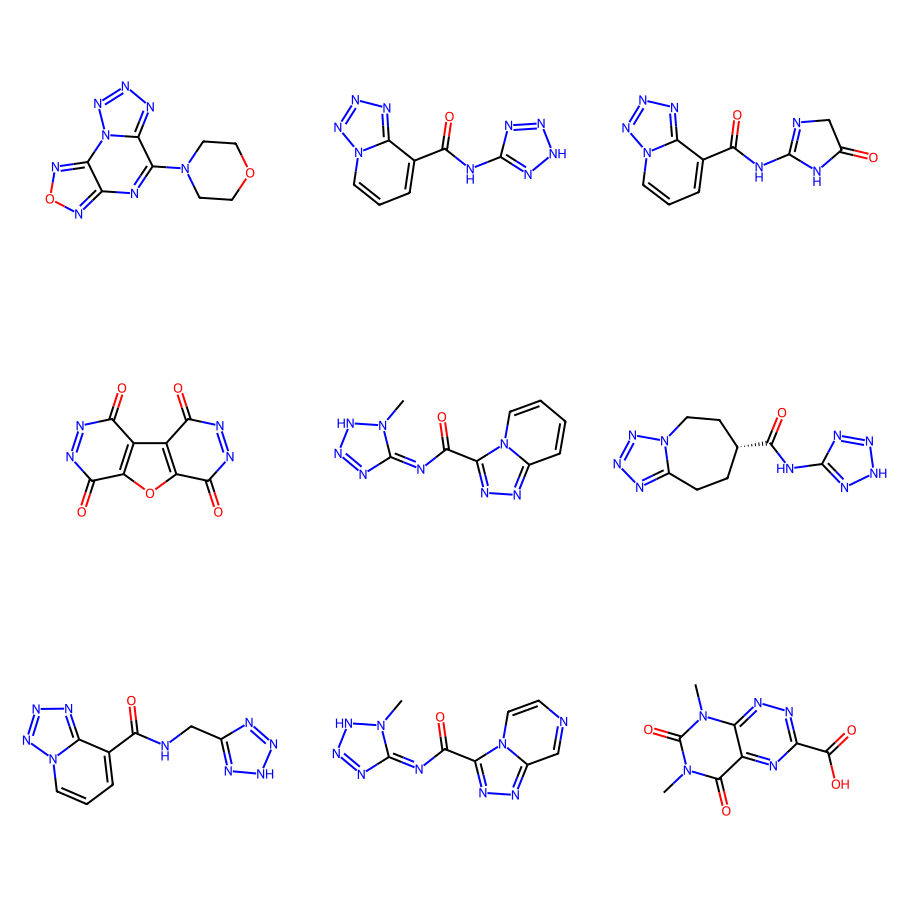

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw

#Tier 1 mols

smiles_list = [
    "C1CN(c2nc3nonc3n3nnnc23)CCO1",
    "O=C(Nc1nn[nH]n1)c1cccn2nnnc12",
    "O=C1CN=C(NC(=O)c2cccn3nnnc23)N1",
    "O=c1nnc(=O)c2c1oc1c(=O)nnc(=O)c12",
    "Cn1[nH]nnc1=NC(=O)c1nnc2ccccn12",
    "O=C(Nc1nn[nH]n1)[C@@H]1CCc2nnnn2CC1",
    "O=C(NCc1nn[nH]n1)c1cccn2nnnc12",
    "Cn1[nH]nnc1=NC(=O)c1nnc2cnccn12",
    "Cn1c(=O)c2nc(C(=O)O)nnc2n(C)c1=O"
]

mols = [Chem.MolFromSmiles(s) for s in smiles_list]

Draw.MolsToGridImage(
    mols,
    molsPerRow=3,
    subImgSize=(300, 300)
)


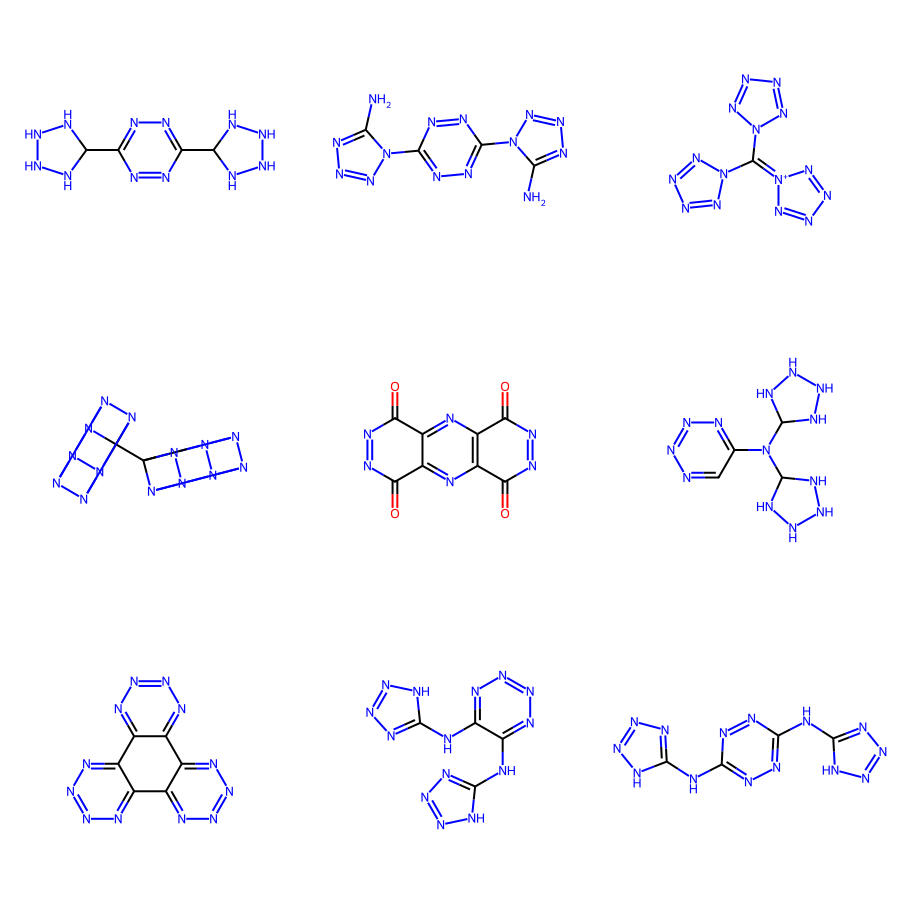

In [ ]:
#Best affinity mols
smiles_list = [
    "n1nc(C2NNNN2)nnc1C1NNNN1",
    "Nc1nnnn1-c1nnc(-n2nnnc2N)nn1",
    "N1=N[N+](=C(n2nnnn2)n2nnnn2)N=N1",
    "N12N3N4N1N1N2N3C41C12N3N4N5N3N1N5N42",
    "O=c1nnc(=O)c2nc3c(=O)nnc(=O)c3nc12",
    "c1nnnnc1N(C1NNNN1)C1NNNN1",
    "n1nnc2c(n1)c1nnnnc1c1nnnnc21",
    "n1n[nH]c(Nc2nnnnc2Nc2nnn[nH]2)n1",
    "n1n[nH]c(Nc2nnc(Nc3nnn[nH]3)nn2)n1",
]

mols = [Chem.MolFromSmiles(s) for s in smiles_list]

Draw.MolsToGridImage(
    mols,
    molsPerRow=3,
    subImgSize=(300, 300)
)

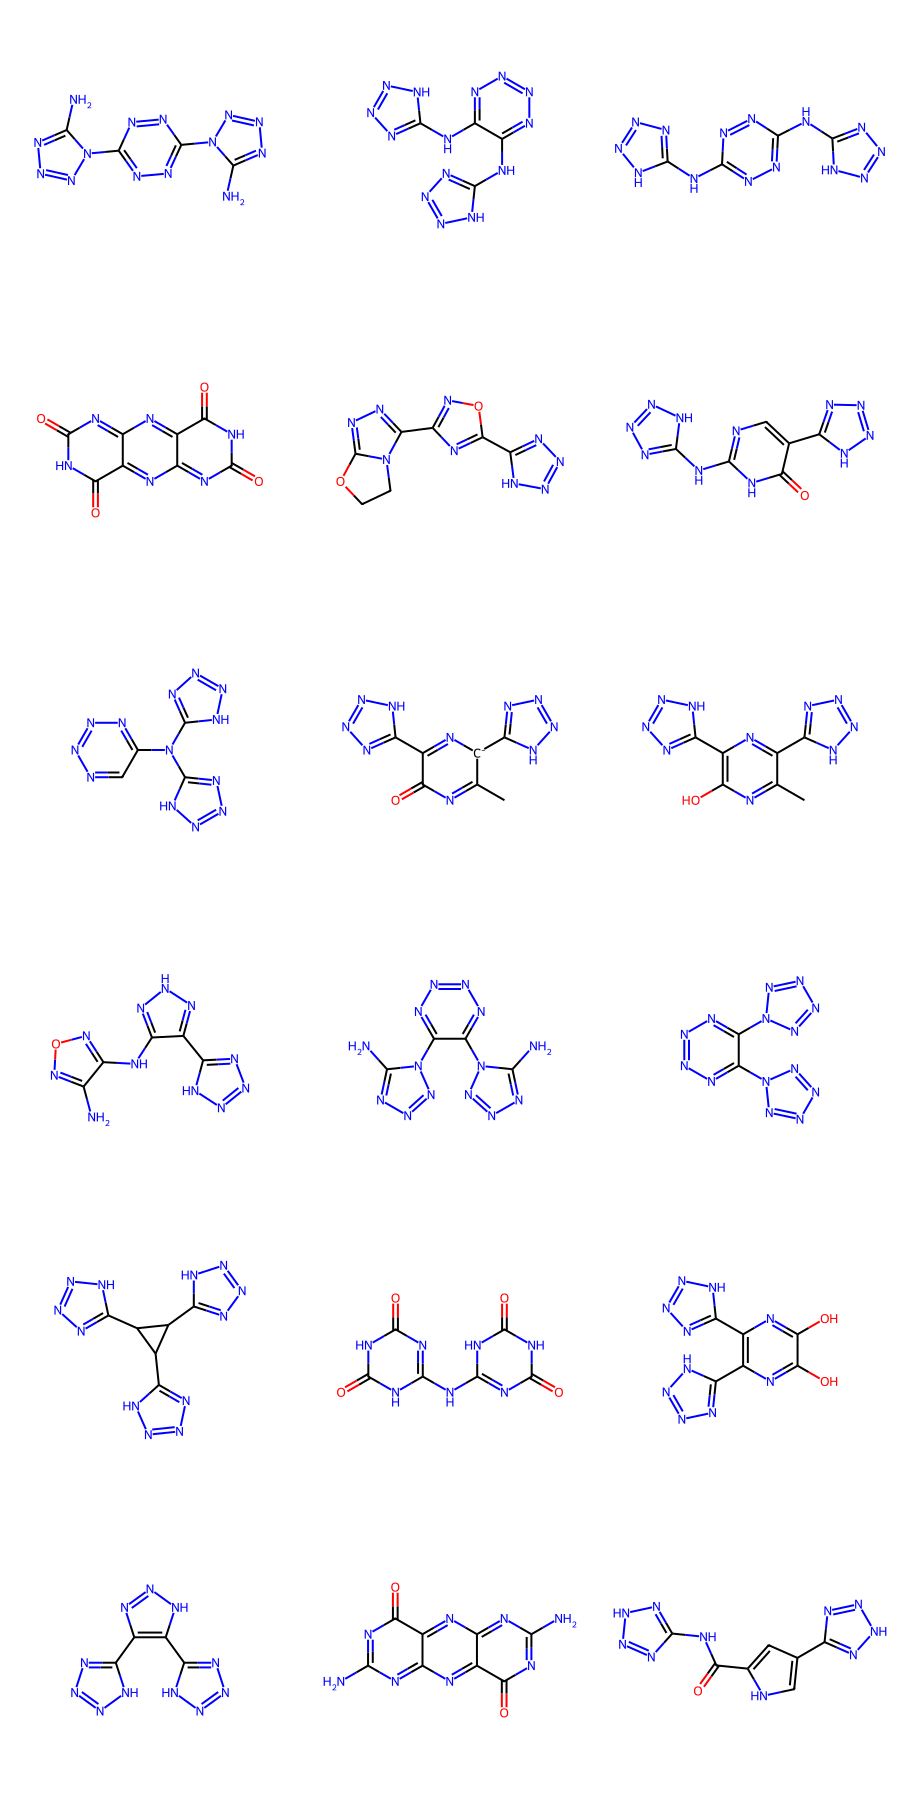

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw

# Tier 2 mols

smiles_list = [
    "Nc1nnnn1-c1nnc(-n2nnnc2N)nn1",
    "n1n[nH]c(Nc2nnnnc2Nc2nnn[nH]2)n1",
    "n1n[nH]c(Nc2nnc(Nc3nnn[nH]3)nn2)n1",
    "O=C1N=c2nc3c(nc2C(=O)N1)=NC(=O)NC3=O",
    "C1Cn2c(nnc2-c2noc(-c3nnn[nH]3)n2)O1",
    "O=c1[nH]c(Nc2nnn[nH]2)ncc1-c1nnn[nH]1",
    "c1nnnnc1N(c1nnn[nH]1)c1nnn[nH]1",
    "Cc1nc(=O)c(-c2nnn[nH]2)n[c-]1-c1nnn[nH]1",
    "Cc1nc(O)c(-c2nnn[nH]2)nc1-c1nnn[nH]1",
    "Nc1nonc1Nc1n[nH]nc1-c1nnn[nH]1",
    "Nc1nnnn1-c1nnnnc1-n1nnnc1N",
    "n1nnc(-n2nnnn2)c(-n2nnnn2)n1",
    "n1n[nH]c(C2C(c3nnn[nH]3)C2c2nnn[nH]2)n1",
    "O=c1nc(Nc2nc(=O)[nH]c(=O)[nH]2)[nH]c(=O)[nH]1",
    "Oc1nc(-c2nnn[nH]2)c(-c2nnn[nH]2)nc1O",
    "n1n[nH]c(-c2nn[nH]c2-c2nnn[nH]2)n1",
    "NC1=NC(=O)c2nc3c(nc2=N1)C(=O)N=C(N)N=3",
    "O=C(Nc1nn[nH]n1)c1cc(-c2nn[nH]n2)c[nH]1",
]

mols = [Chem.MolFromSmiles(s) for s in smiles_list]

Draw.MolsToGridImage(
    mols,
    molsPerRow=3,
    subImgSize=(300, 300)
)


